<a href="https://colab.research.google.com/github/alexsocha0-alt/lab-image-classification-using-convolutional-neural-networks/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4519s 27us/step


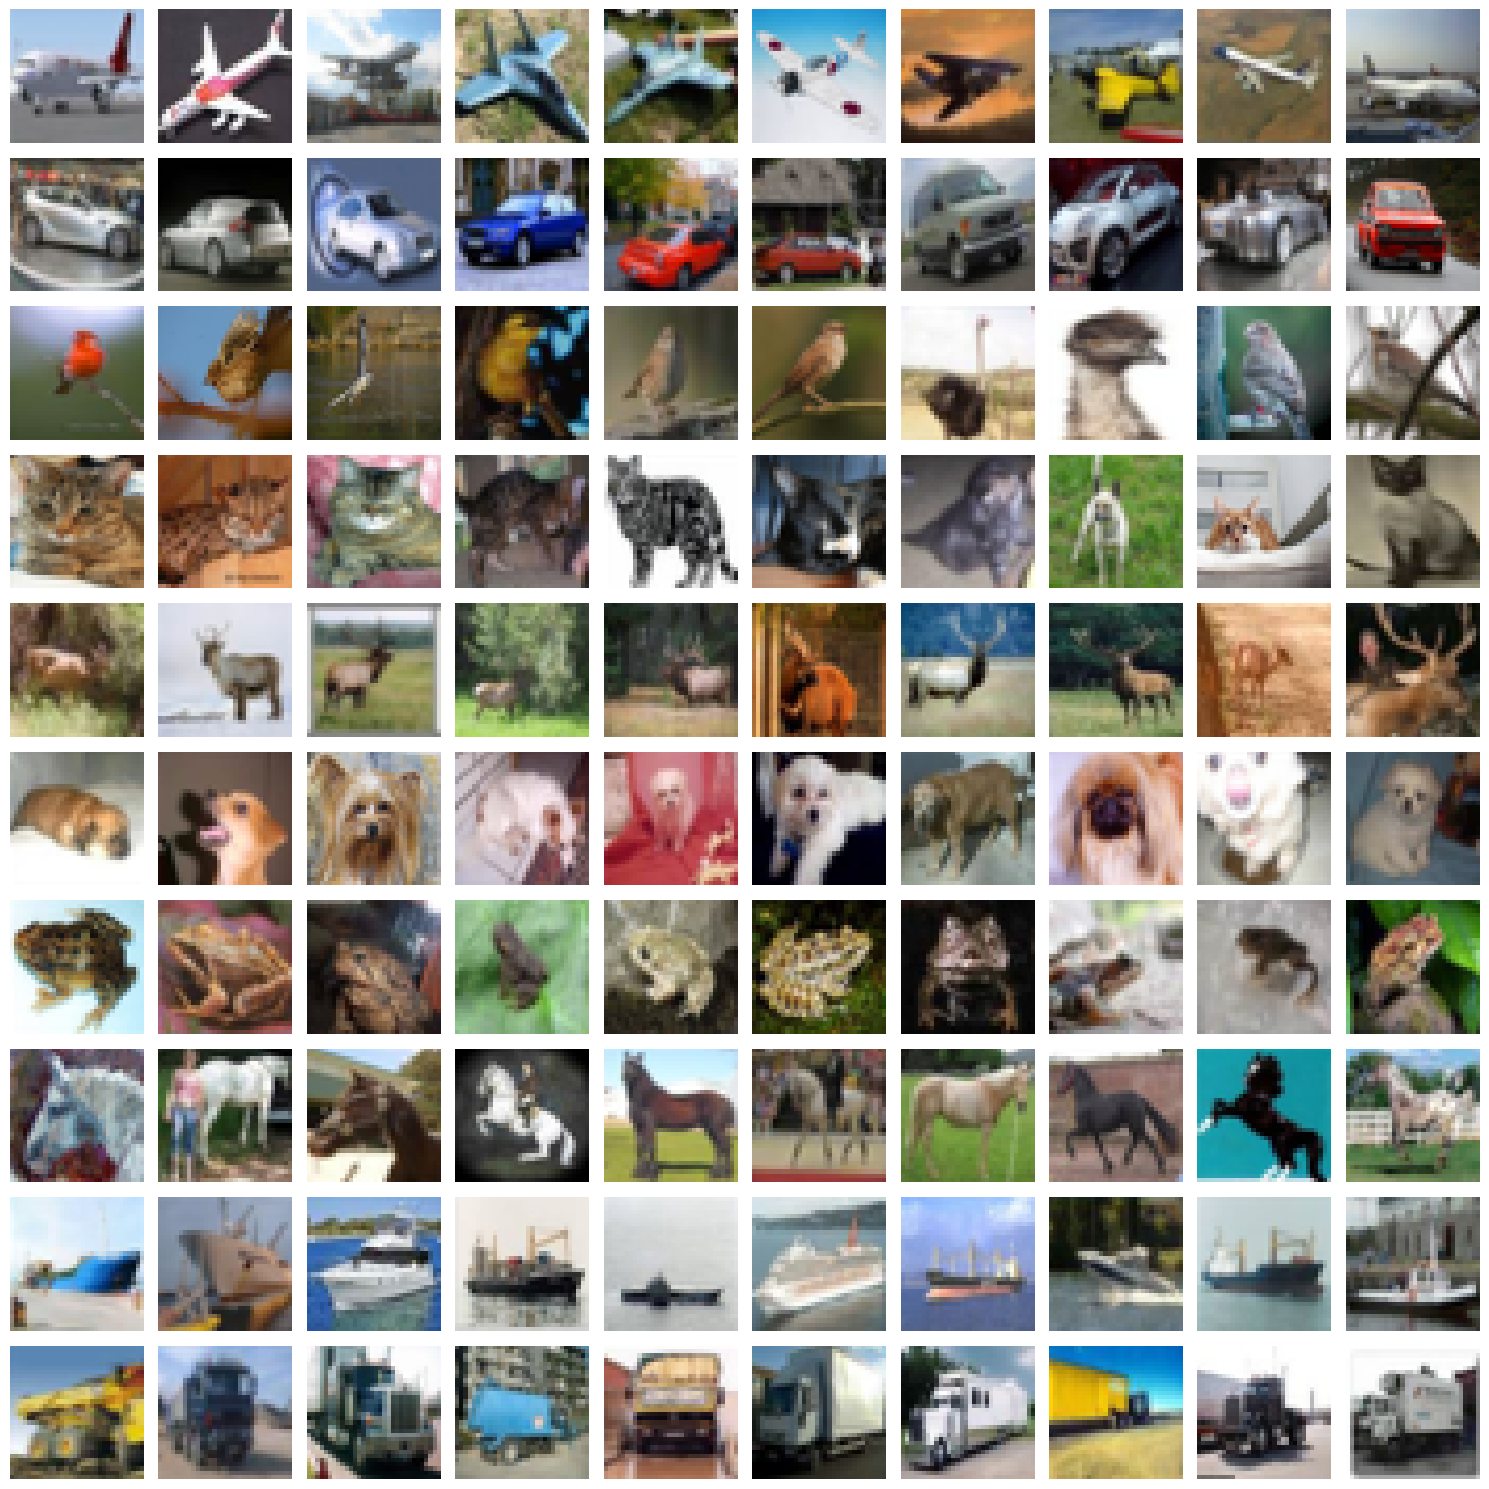

In [19]:
# Your code here :

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Show 10 random images from each class
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(15, 15))

for class_id in range(10):
    idx = np.where(np.argmax(y_train, axis=1) == class_id)[0]
    random_idx = np.random.choice(idx, 10, replace=False)

    for j, img_idx in enumerate(random_idx):
        plt.subplot(10, 10, class_id * 10 + j + 1)
        plt.imshow(x_train[img_idx])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [5]:
from keras.backend import clear_session
clear_session()

In [20]:
# Your code here :
from tensorflow.keras import models, layers

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(100, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [21]:
# Your code here :
model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test)
)

*   Plot the cross entropy loss curve and the accuracy curve

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.1858 - loss: 2.2392 - val_accuracy: 0.2380 - val_loss: 2.1778
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2625 - loss: 2.1238 - val_accuracy: 0.2846 - val_loss: 2.0675
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3042 - loss: 2.0206 - val_accuracy: 0.3115 - val_loss: 1.9810
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3251 - loss: 1.9433 - val_accuracy: 0.3382 - val_loss: 1.9129
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3428 - loss: 1.8943 - val_accuracy: 0.3365 - val_loss: 1.8895
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3523 - loss: 1.8608 - val_accuracy: 0.3492 - val_loss: 1.8464
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3655 - loss: 1.8301 - val_accuracy: 0.3510 - val_loss: 1.8404
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3702 - loss: 1.8065 - val_accuracy: 0.3811 - v

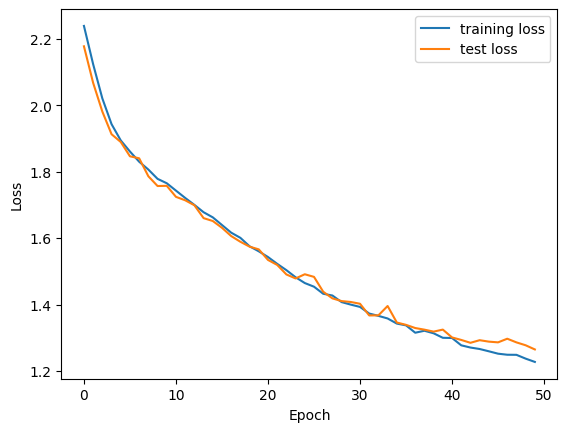

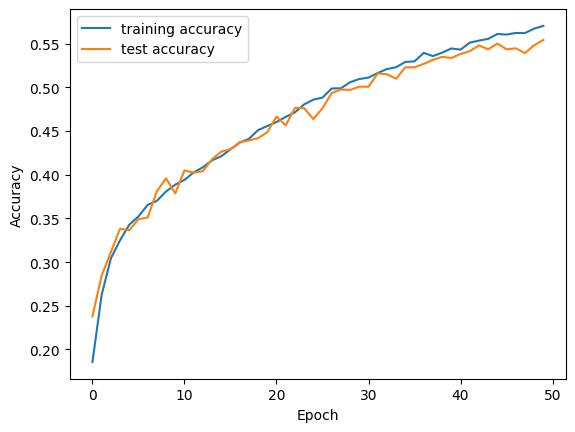

In [25]:
model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test)
)

plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
## Interpretation of curves

The loss decreases steadily for both the training and test datasets, showing that the model is learning effectively. The accuracy increases throughout training, reaching approximately 57% on the training set and 55% on the test set. Since the training and test curves stay close together, there is no significant sign of overfitting, although the overall accuracy could be improved with a more complex CNN architecture.


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [9]:
from keras.backend import clear_session
clear_session()

In [29]:
# Your code here :
from tensorflow.keras import models, layers

vgg_model = models.Sequential()

vgg_model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
vgg_model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
vgg_model.add(layers.MaxPooling2D((2, 2)))

vgg_model.add(layers.Flatten())
vgg_model.add(layers.Dense(128, activation="relu"))
vgg_model.add(layers.Dense(10, activation="softmax"))

vgg_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [30]:
# Your code here :
vgg_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_history = vgg_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.1867 - loss: 2.2303 - val_accuracy: 0.2583 - val_loss: 2.1314
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2784 - loss: 2.0501 - val_accuracy: 0.2837 - val_loss: 2.0436
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3177 - loss: 1.9501 - val_accuracy: 0.3411 - val_loss: 1.8829
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.3439 - loss: 1.8765 - val_accuracy: 0.3504 - val_loss: 1.8597
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3584 - loss: 1.8290 - val_accuracy: 0.3740 - val_loss: 1.7877
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3770 - loss: 1.7763 - val_accuracy: 0.3739 - val_loss: 1.7573
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3907 - loss: 1.7371 - val_accuracy: 0.4016 - val_loss: 1.7088
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4006 - loss: 1.7085 - val_accuracy: 0.4090 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


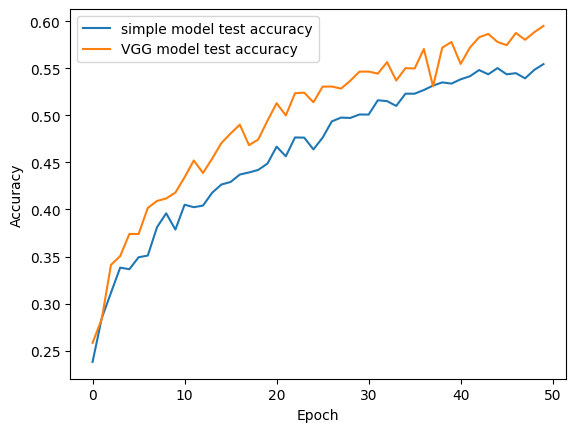

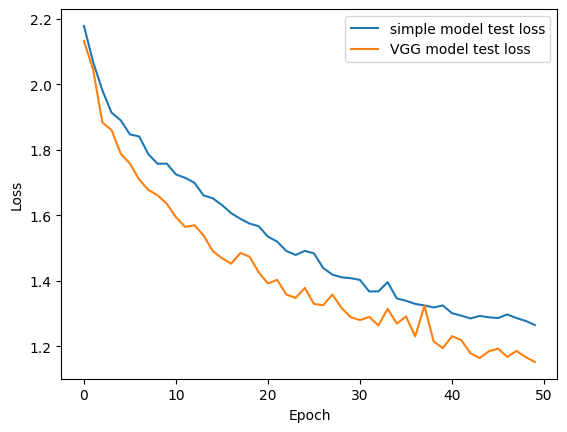

In [31]:
# Your code here :
plt.plot(history.history["val_accuracy"], label="simple model test accuracy")
plt.plot(vgg_history.history["val_accuracy"], label="VGG model test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["val_loss"], label="simple model test loss")
plt.plot(vgg_history.history["val_loss"], label="VGG model test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Comment on the observation**

*(Double-click or enter to edit)*
The VGG model performs better than the simple CNN model. It achieves higher validation accuracy and lower validation loss throughout training. Adding an extra convolutional layer allows the network to learn more complex image features, resulting in better classification performance.
...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [13]:
# Your code here :

**Comment here :**
The confusion matrix shows that the model performs better on some classes than others. Classes with visually similar objects are more often confused, for example cats and dogs, or trucks and automobiles. This is expected because CIFAR-10 contains small 32x32 images where similar classes can be hard to distinguish.

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [32]:
# Your code here :

test_loss, test_accuracy = vgg_model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5950 - loss: 1.1519
Test accuracy: 0.5950000286102295


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [33]:
# Your code here :
from tensorflow.keras import models, layers

full_vgg_model = models.Sequential()

full_vgg_model.add(layers.Resizing(64, 64, input_shape=(32, 32, 3)))

full_vgg_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.MaxPooling2D((2, 2)))

full_vgg_model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.MaxPooling2D((2, 2)))

full_vgg_model.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
full_vgg_model.add(layers.MaxPooling2D((2, 2)))

full_vgg_model.add(layers.Flatten())
full_vgg_model.add(layers.Dense(128, activation="relu"))
full_vgg_model.add(layers.Dense(10, activation="softmax"))

full_vgg_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 49s 476ms/step - accuracy: 0.4218 - loss: 1.6432 - val_accuracy: 0.4328 - val_loss: 1.6051
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 463ms/step - accuracy: 0.4404 - loss: 1.5865 - val_accuracy: 0.4460 - val_loss: 1.5599
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 439ms/step - accuracy: 0.4580 - loss: 1.5403 - val_accuracy: 0.4613 - val_loss: 1.5401
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 453ms/step - accuracy: 0.4731 - loss: 1.5038 - val_accuracy: 0.4907 - val_loss: 1.4402
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 443ms/step - accuracy: 0.4869 - loss: 1.4609 - val_accuracy: 0.4836 - val_loss: 1.4905
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 449ms/step - accuracy: 0.4988 - loss: 1.4274 - val_accuracy: 0.4927 - val_loss: 1.4532
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 453ms/step - accuracy: 0.5118 - loss: 1.3932 - val_accuracy: 0.4865 - val_loss: 1.4160
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 439ms/step - accuracy: 0.5220 - loss: 1.3636 - val_accu

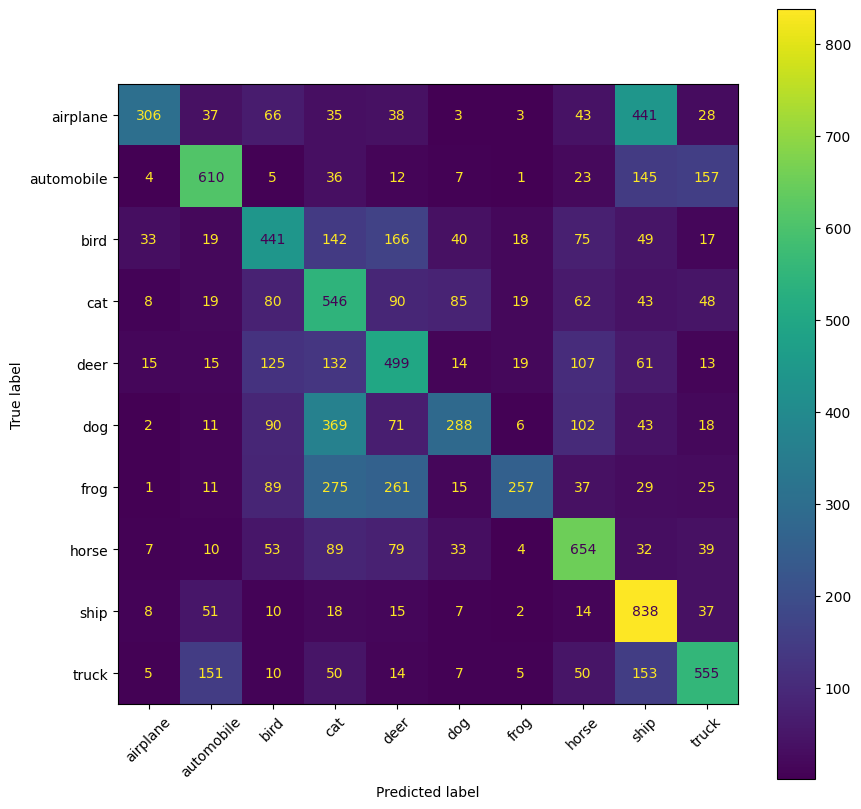

In [36]:
# Your code here :

full_vgg_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

full_vgg_history = full_vgg_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_test, y_test)
)

test_loss, test_accuracy = full_vgg_model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy)

y_pred_probs = full_vgg_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
Activation functions introduce non-linearity into the neural network, allowing it to learn complex patterns. Without activation functions, the network would behave like a simple linear model regardless of the number of layers.
_

2 - Key Differences between sigmoid and softmax:
Sigmoid is mainly used for binary classification and outputs an independent probability between 0 and 1. Softmax is used for multi-class classification and converts the outputs into probabilities that sum to 1, selecting the most likely class.
_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
Binary crossentropy is used for binary classification problems with two classes. Categorical crossentropy is used for multi-class classification where each sample belongs to exactly one class and the labels are one-hot encoded.

_
